In [1]:
%cd ../

/home/student/pubtrends


In [2]:
!pwd

/home/student/pubtrends


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm import tqdm

%matplotlib inline
plt.rcParams["axes.labelsize"] = 16.
plt.rcParams["xtick.labelsize"] = 14.
plt.rcParams["ytick.labelsize"] = 14.
plt.rcParams["legend.fontsize"] = 12.
plt.rcParams["figure.figsize"] = [13., 9.]

In [11]:
import logging

import numpy as np
import pandas as pd

from pysrc.papers.db.loader import Loader
from pysrc.papers.db.postgres_connector import PostgresConnector
from pysrc.papers.db.postgres_utils import preprocess_search_query_for_postgres, \
    process_bibliographic_coupling_postgres, process_cocitations_postgres, no_stemming_filter
from pysrc.papers.utils import crc32, SORT_MOST_CITED, SORT_MOST_RECENT, preprocess_doi, \
    preprocess_search_title

logger = logging.getLogger(__name__)

import logging
import html
import pandas as pd
import numpy as np
import networkx as nx
import random
import hashlib
from tqdm.auto import tqdm

from pysrc.prediction.ss_arxiv_loader import SSArxivLoader
from pysrc.prediction.ss_pubmed_loader import SSPubmedLoader
from pysrc.papers.db.pm_postgres_loader import PubmedPostgresLoader
from pysrc.prediction.predict_analyzer import PredictAnalyzer
from pysrc.papers.config import PubtrendsConfig
from pysrc.papers.db.ss_postgres_loader import SemanticScholarPostgresLoader
from pysrc.papers.db.postgres_connector import PostgresConnector
from collections import defaultdict



class CustomLoader(SemanticScholarPostgresLoader):
    def __init__(self, config):
        super(CustomLoader, self).__init__(config)

    def load_func(self, limit=100):
        self.check_connection()
        if limit is None:
            query = '''SELECT ssid, aux::json->'authors' FROM sspublications'''
        else:
            query = f'''
                    SELECT ssid, aux::json->'authors' FROM sspublications LIMIT {limit}
            '''
        result = defaultdict(list)
        with self.postgres_connection.cursor() as cursor:
            cursor.execute(query)
            for item in cursor:
                ind, names = item
                for i, el in enumerate(names):
                    result[el['name']].append((ind, int(i == 0)))
            return result
    
    def custom_query(self, query):
        self.check_connection()
        with self.postgres_connection.cursor() as cursor:
            cursor.execute(query)
            return cursor.fetchall()
    
    def create_subsample(self, threshold=0.01, seed=42):
        self.check_connection()
        random.seed(seed)
        ssids, crc32ids = [], []
        query = '''select ssid, crc32id from sspublications'''
        with self.postgres_connection.cursor() as cursor:
            cursor.execute(query)
            for item in cursor:
                if random.random() < threshold:
                    ss, crc = item
                    ssids.append(ss)
                    crc32ids.append(crc)
            return ssids, crc32ids


class CustomWriter(PostgresConnector):

    def __init__(self, config):
        super(CustomWriter, self).__init__(config, readonly=False)
        
    def insert_table_publications(self, ids):
        self.check_connection()
        query = f'''CREATE TABLE IF NOT EXISTS sspublications_sample AS 
            (SELECT * FROM sspublications WHERE ssid IN ({', '.join(map(lambda x: "'" + str(x) + "'", ids))}))'''
        with self.postgres_connection.cursor() as cursor:
            cursor.execute(query)
            self.postgres_connection.commit()
        
    def insert_table_citations(self, ids):
        self.check_connection()
        query = f'''CREATE TABLE IF NOT EXISTS sscit_sample AS 
            (SELECT * FROM sscitations WHERE crc32id_in IN ({', '.join(map(lambda x: "'" + str(x) + "'", ids))}));
            create index if not exists sscit_crc32id_in on sscit_sample (crc32id_in);'''
        with self.postgres_connection.cursor() as cursor:
            cursor.execute(query)
            self.postgres_connection.commit()
    
    def execute_custom_query(self, query):
        try:
            self.check_connection()
            with self.postgres_connection.cursor() as cursor:
                cursor.execute(query)
                self.postgres_connection.commit()
        except Exception as e:
            print(e)



In [12]:
config = PubtrendsConfig(test=False)
loader = CustomLoader(config)
writer = CustomWriter(config)

### Authors df

In [6]:
%%time
query = 'select * from authors;'
data_authors = loader.custom_query(query)

CPU times: user 7.28 s, sys: 1.15 s, total: 8.43 s
Wall time: 12.4 s


In [7]:
authors = pd.DataFrame(data=data_authors, columns=['author_id', 'author_name', 
                                                   'productivity', 'first_year_pub', 
                                                   'last_year_pub', 'total_papers', 
                                                   'is_main_ratio', "sociality", 
                                                   'total_venues', 'mean_citations', 
                                                   'top_citations', 'h_1970', 'h_1980', 'h_1990', 'h_2000', 'h_2010', 'h_2020'])
authors_df = authors.set_index('author_id')

### Papers df

In [8]:
%%time
query = 'select distinct ssid, year, c2, c5, c_all, num_of_authors, num_words_title, num_words_abs, lang from sspublications_sample;'
data_papers = loader.custom_query(query)

CPU times: user 1.15 s, sys: 180 ms, total: 1.33 s
Wall time: 4.99 s


In [9]:
papers_df = pd.DataFrame(data=data_papers, columns=['ssid', 'year', 'c2', 
                                                    'c5', 'c_all', 'num_of_authors', 'num_words_title', 'num_words_abs', 'lang'])
papers_df = papers_df.set_index('ssid')

In [10]:
papers_df.sort_values('c_all')

,year,c2,c5,c_all,num_of_authors,num_words_title,num_words_abs,lang
ssid,,,,,,,,
23e4a656ae4b11fabd7d4d649ba511c9d537ab22,1989.0,0,0,0,4,5,0,es
300d0c0d4f8a6eb2e42adb6e2f6a83fb23430ae6,2003.0,0,0,0,1,10,143,en
e02faa5176c513cd2243f9a0a94fc4481da8fe3c,2018.0,0,0,0,1,3,0,en
044996bd939f900551ae45c9bcc3a340eb498e99,1840.0,0,0,0,1,9,0,en
b0127c9e90f9028dafdecc50edcbea7ed41b010b,2004.0,0,0,0,1,4,0,ko
...,...,...,...,...,...,...,...,...
eb2beacef72033cfc3364de191e703e363b7721a,1982.0,44,110,10574,1,9,0,en
da0d3bd2c852f480632318dc51d6768e8615f248,1995.0,6,51,12151,3,10,164,en
9c4fb83f9c95c677ca5fa7e478de438b733a002d,2005.0,154,1093,12434,3,14,186,en


### Venues df

In [11]:
%%time
query = 'select * from venues;'
data_venues = loader.custom_query(query)

CPU times: user 96.7 ms, sys: 11.4 ms, total: 108 ms
Wall time: 159 ms


In [12]:
venues_df = pd.DataFrame(data=data_venues, columns=[ 'venue_id', 'venue_name',
                                                    'total_papers', "total_citations", 
                                                    'avg_citations_paper', "avg_citations_year", 'avg_papers_year'])
venues_df = venues_df.set_index('venue_id')

In [13]:
venues_df.sort_values('total_citations')

,venue_name,total_papers,total_citations,avg_citations_paper,avg_citations_year,avg_papers_year
venue_id,,,,,,
9137,bibliotheca microbiologica,3,0,0E-20,0E-20,1.5000000000000000
40528,jiangxi building materials,3,0,0E-20,0E-20,3.0000000000000000
40524,wjm,1,0,0E-20,0E-20,1.00000000000000000000
40523,contemporary biomedicine,1,0,0E-20,0E-20,1.00000000000000000000
40520,"the brooklyn journal of corporate, financial a...",2,0,0E-20,0E-20,1.00000000000000000000
...,...,...,...,...,...,...
77,physical review letters,1095,63093,57.6191780821917808,1001.4761904761904762,17.3809523809523810
923,proceedings of the national academy of science...,664,68129,102.6039156626506024,801.5176470588235294,7.8117647058823529
274,the journal of biological chemistry,1322,80859,61.1641452344931921,1092.6891891891891892,17.8648648648648649


In [14]:
%%time
q = '''select * from venues_papers_authors;'''
sub_data = loader.custom_query(q)

CPU times: user 773 ms, sys: 243 ms, total: 1.02 s
Wall time: 1.79 s


In [15]:
sub_df = pd.DataFrame(data=sub_data, columns=['venue_id', 'author_id', 'ssid'])
sub_df.set_index('ssid')

,venue_id,author_id
ssid,,
82ab5fa810ab5581efa3305dfae6422c2c1f8e91,1,2897078
78ee6b6ff4c783dfdf4ab044f77a3a95e7225a12,1,340303
f864ec7d3e36cfd6fea9340bd9b65ca8e6a3d497,1,334193
b4bc5dc1f502bf2694ef8fd3499f5a5f15ef78dd,1,1546482
8a77be2e34dd8ef197e45e240dcaa14f1e63f5c6,1,1211664
...,...,...
81ce00fea29c105eb2410ea029fda5b1ba4dd290,70592,3173792
efcf59d6c40dbd1e242b249dff4d3fce5ed7b931,70593,3173836
efcf59d6c40dbd1e242b249dff4d3fce5ed7b931,70593,3173837


In [16]:
papers_df.merge(sub_df, on='ssid', how='left').sort_values('c_all')

,ssid,year,c2,c5,c_all,num_of_authors,num_words_title,num_words_abs,lang,venue_id,author_id
0,23e4a656ae4b11fabd7d4d649ba511c9d537ab22,1989.0,0,0,0,4,5,0,es,NaN,NaN
1815774,3dff8849e9e31cc86543bb88272e0f3eff4f3b8a,2020.0,0,0,0,6,8,0,es,5071.0,577966.0
1815773,3dff8849e9e31cc86543bb88272e0f3eff4f3b8a,2020.0,0,0,0,6,8,0,es,5071.0,48040.0
1815772,3dff8849e9e31cc86543bb88272e0f3eff4f3b8a,2020.0,0,0,0,6,8,0,es,5071.0,48035.0
1815771,3dff8849e9e31cc86543bb88272e0f3eff4f3b8a,2020.0,0,0,0,6,8,0,es,5071.0,48044.0
...,...,...,...,...,...,...,...,...,...,...,...
2162152,7dd5f8774e944b38f6d75434a50bcb9b8db4a755,1977.0,106,418,12731,1,4,12,en,NaN,NaN
899814,59f132e6071feed20b3e1645bb137bc3178eb985,2010.0,1056,4170,12769,4,5,27,en,46968.0,2721622.0
899815,59f132e6071feed20b3e1645bb137bc3178eb985,2010.0,1056,4170,12769,4,5,27,en,46968.0,2721621.0
899816,59f132e6071feed20b3e1645bb137bc3178eb985,2010.0,1056,4170,12769,4,5,27,en,46968.0,645990.0


In [17]:
%%time
q = '''select lang from sspublications_sample;'''
ls = loader.custom_query(q)
ls = [item[0] for item in ls]

CPU times: user 363 ms, sys: 35.7 ms, total: 399 ms
Wall time: 2.01 s


In [18]:
counted_langs = dict(Counter(ls))
sorted_langs = list(counted_langs.items())
sorted_langs.sort(key=lambda x: -x[1])

In [19]:
def plot_top_n_langs(ls, n=10, func=None, lbl=''):
    if func is None:
        df = pd.DataFrame(data=ls[:n], columns=['lang', f'''num_of_papers {f"({lbl})" if lbl else ''}'''])
    else:
        df = pd.DataFrame(data={'lang': [x for x, y in ls[:n]], 
                                f'''num_of_papers {f"({lbl})" if lbl else ''}''': [func(y) for x, y in ls[:n]]})
    
    ax = sns.barplot(x='lang', y=f'''num_of_papers {f"({lbl})" if lbl else ''}''', data=df)
    plt.title('Distribution of languages')
    ax.bar_label(ax.containers[0]);
    

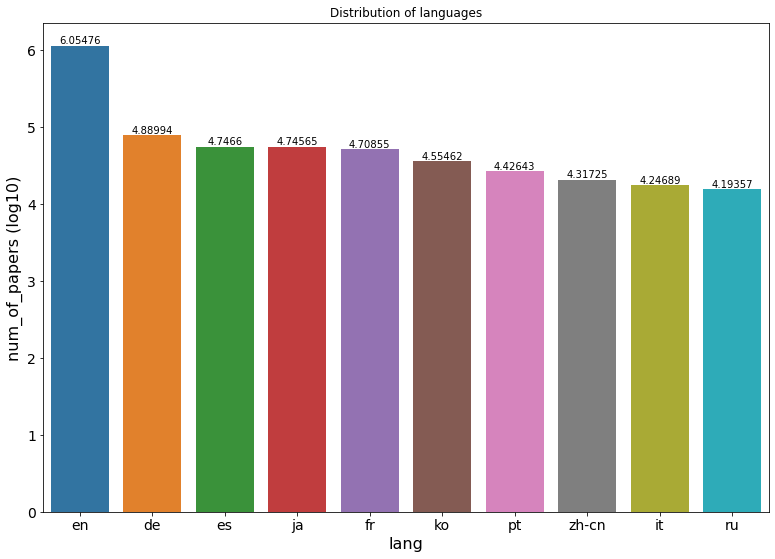

In [20]:
plot_top_n_langs(sorted_langs, n=10, func=np.log10, lbl='log10')

### Язык абстракта vs язык заголовка

In [21]:
with open('tmp_data/title_langs.txt') as f:
    titles = [item.strip().split() for item in f.readlines()]
    
with open('tmp_data/title_langs.txt') as f:
    absracts = [item.strip().split() for item in f.readlines()]

In [22]:
d_abs = {key: val for key, val in absracts}
d_titles = {key: val for key, val in titles}

In [23]:
print(f'Number of different lang for title and abstract: {sum(d_abs[key] != d_titles[key] for key in d_abs)}')

Number of different lang for title and abstract: 0


### Распределение кол-ва авторов для топ-100 журналов

In [24]:
q = '''select venue_id, total_citations, venue_name from venues order by total_citations desc limit 100;'''
top_venues = loader.custom_query(q)

In [25]:
d_venues = {key: (cit, name) for key, cit, name in top_venues}
authors_venues = defaultdict(list)

In [26]:
%%time
q = '''select distinct v.ssid, venue_id, num_of_authors from sspublications_sample ss 
left join venues_papers_authors v on ss.ssid = v.ssid order by num_of_authors desc;'''
authors_data_venues = loader.custom_query(q)

CPU times: user 253 ms, sys: 61.9 ms, total: 314 ms
Wall time: 9.25 s


In [27]:
for ssid, venue_id, n_authors in authors_data_venues:
    if ssid is not None and venue_id is not None and venue_id in d_venues:
        authors_venues[venue_id].append(n_authors)
authors_venues = dict(authors_venues)

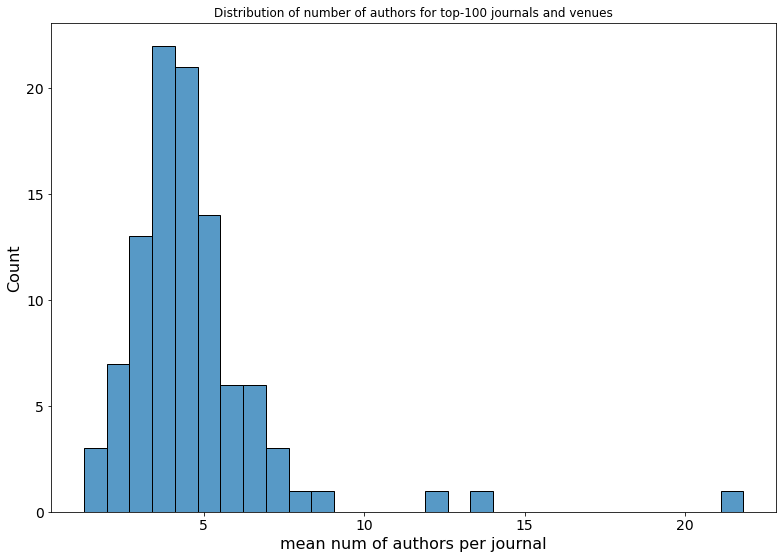

In [28]:
ls = pd.Series([np.mean(authors_venues[key]) for key in authors_venues], name='mean num of authors per journal')
sns.histplot(ls);
plt.title('Distribution of number of authors for top-100 journals and venues');

### Распределение кол-ва статей для топ-100 журналов

In [29]:
q = '''select venue_id, total_citations, venue_name, total_papers from venues order by total_citations desc limit 100;'''
top_venues = loader.custom_query(q)

d_venues = {key: n_papers for key, cit, name, n_papers in top_venues}

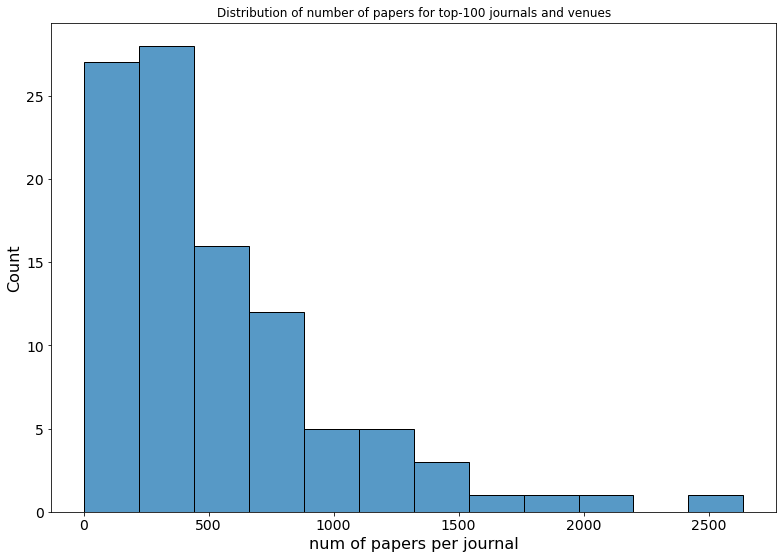

In [30]:
ls = pd.Series(list(d_venues.values()), name='num of papers per journal')
sns.histplot(ls);
plt.title('Distribution of number of papers for top-100 journals and venues');

(array([701245.,  13366.,  23285.,  24132.,  25586., 181919., 384912.,
        169055.,  48445.,  11590.]),
 array([   0,   10,   20,   30,   40,   50,  100,  200,  300,  500, 1000]),
 <BarContainer object of 10 artists>)

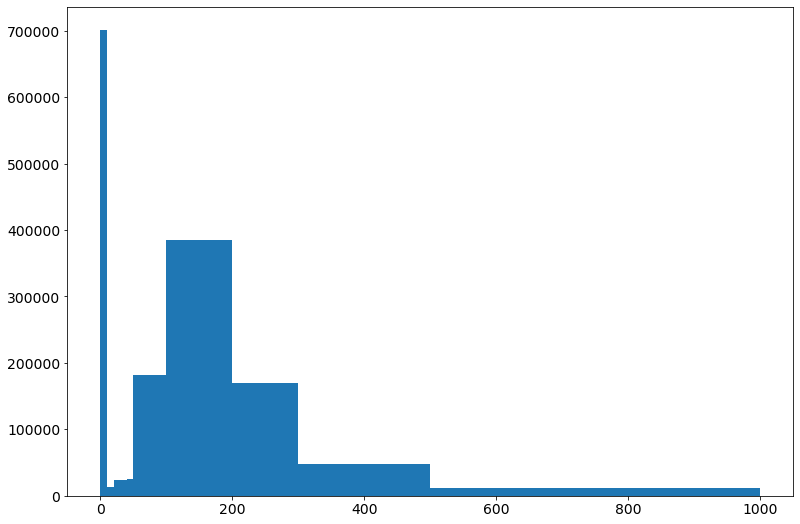

In [31]:
plt.hist(papers_df['num_words_abs'], bins=[0, 10, 20, 30, 40, 50, 100, 200, 300, 500, 1000])

(array([4.18751e+05, 6.74608e+05, 3.95195e+05, 7.52730e+04, 1.74800e+04,
        3.53300e+03, 3.22000e+02, 0.00000e+00, 0.00000e+00, 1.00000e+00]),
 array([ 0. ,  6.5, 13. , 19.5, 26. , 32.5, 39. , 45.5, 52. , 58.5, 65. ]),
 <BarContainer object of 10 artists>)

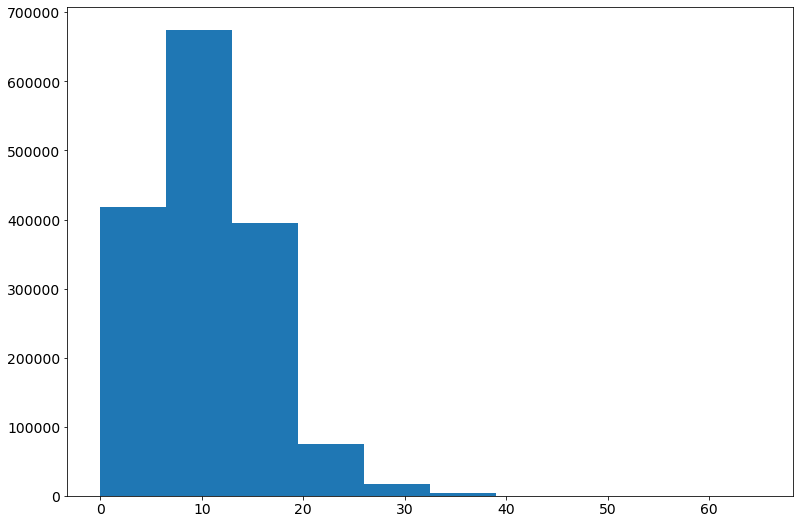

In [32]:
plt.hist(papers_df['num_words_title'])

(array([931243., 142854.,  77007.,  51536.,  38385.,  30502.,  25020.,
         21395.,  18550.,  16188.,  94693.,  44212.,  41276.,  21435.,
         10306.,  13465.,   5515.,   1127.]),
 array([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,   10,
          20,   30,   50,   75,  100,  200,  500, 1000]),
 <BarContainer object of 18 artists>)

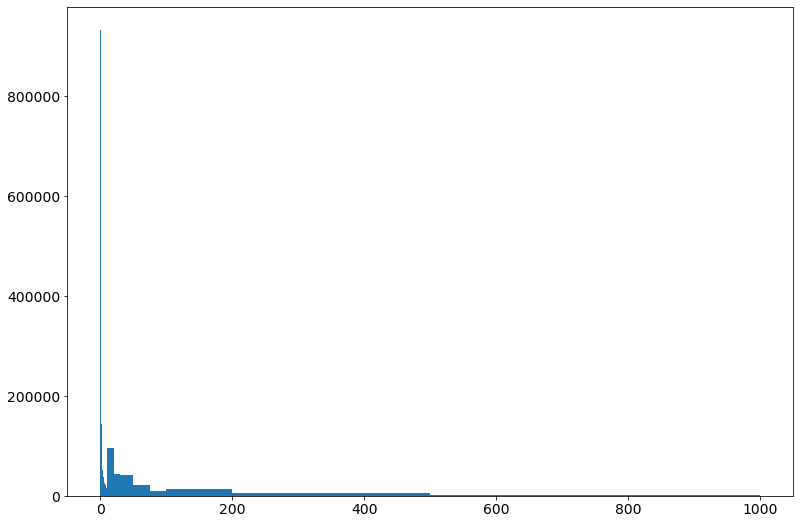

In [33]:
plt.hist(papers_df['c_all'], bins=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 20, 30, 50, 75, 100, 200, 500, 1000])

### Модель

In [234]:
!python3 -m pip install catboost

     |████████████████████████████████| 67.4 MB 3.2 MB/s eta 0:00:01
     |████████████████████████████████| 20.6 MB 83.1 MB/s eta 0:00:01    |███████▌                        | 4.8 MB 83.1 MB/s eta 0:00:01


In [17]:
papers_df

,c2,c5,c_all,num_words_title,num_words_abs,lang
ssid,,,,,,
48a6d2645c62dd994d5b42923a0a4f6a2014978f,0,0,0,3,0,ko
665655aba7427b2501d25c8c16c14fc84ba76dd2,0,0,0,2,0,fr
3aa7633b9f1c9410460e841142133bd2cebfc31f,0,0,0,8,98,ko
a3d03f810e90ba148be33e8b6c93656ecfb4280c,0,0,0,16,0,en
9c46bdf1d44862e46db5059b67caaccabb983181,0,0,0,13,265,id
...,...,...,...,...,...,...
7c085a4cdb9709e6b5338e9904ebd31774ed0a92,2,4,5,7,0,en
8c5ee1b39c85432059c885b1f65b812e28d7931d,0,1,10,11,82,en
0a272ce68e767944d2b4b008c2a4e071ed7fe152,0,0,0,3,0,ja


In [18]:
authors_df.sort_values('total_papers')

,author_name,productivity,first_year_pub,last_year_pub,total_papers,is_main_ratio,sociality,total_venues,mean_citations,top_citations,h_1970,h_1980,h_1990,h_2000,h_2010,h_2020
author_id,,,,,,,,,,,,,,,,
3114427,Malcolm Green,0.05000000000000000000,2002.0,2002.0,1,1.00000000000000000000,6.0000000000000000,0,2.0000000000000000,2,0,0,0,0,0,1
2059558,D ShatilAbuHenaM,0.16666666666666666667,2016.0,2016.0,1,0E-20,2.0000000000000000,0,0E-20,0,0,0,0,0,0,0
2059559,Gustavo Panacioni Ribas,0.20000000000000000000,2017.0,2017.0,1,1.00000000000000000000,0E-20,0,0E-20,0,0,0,0,0,0,0
2059560,Bambang Pramudya Noorachmat,0.25000000000000000000,2018.0,2018.0,1,0E-20,3.0000000000000000,0,0E-20,0,0,0,0,0,0,0
2059562,H K Panda,0.04000000000000000000,1997.0,1997.0,1,1.00000000000000000000,2.0000000000000000,0,0E-20,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
373,Li Li,6.6410256410256410,1983.0,2021.0,259,0.33590733590733590734,6.0810810810810811,198,9.9305019305019305,263,0,0,1,3,9,26
18586,Kristin Persson,15.3529411764705882,2005.0,2017.0,261,0.99616858237547892720,0.00383141762452107280,0,0.06896551724137931034,11,0,0,0,0,0,2
10474,Wei Li,10.0370370370370370,1995.0,2021.0,271,0.24354243542435424354,32.0147601476014760,253,14.3690036900369004,301,0,0,0,2,8,33


In [34]:
papers_venues_1 = {}
for v, a, p in sub_df.values:
    papers_venues_1[p] = v

In [35]:
def calc_author_features_for_paper(t):
    return t[0], authors_df.loc[t[1]].iloc[[0, -1]].mean()[['productivity', 'is_main_ratio', "sociality", 
                                                   'total_venues', 'mean_citations', 
                                                   'top_citations', 'h_1970', 'h_1980', 'h_1990', 
                                                            'h_2000', 'h_2010', 'h_2020']]


def calc_venue_features_for_paper(t):
    return t[0], venues_df.loc[t[1]].median()[['total_papers', 'total_citations', 
                                                              'avg_citations_paper', 'avg_citations_year', 
                                                              'avg_papers_year']]

In [36]:
authors_papers = loader.custom_query('select ssid, array_agg(author_id) from authors_papers group by ssid;')

In [37]:
q = ''' select ssid, array_agg(vpa.venue_id) from venues_papers_authors as vpa group by ssid;'''

venues_papers = [(key, list(set(item))) for key, item in loader.custom_query(q)]

In [38]:
from concurrent.futures import ProcessPoolExecutor


def process_authors_features_for_paper(authors_papers, num_workers=4):

    with ProcessPoolExecutor(max_workers=num_workers) as pool:
        with tqdm(total=len(authors_papers)) as progress:
            futures = []

            for item in authors_papers:
                future = pool.submit(calc_author_features_for_paper, item)
                future.add_done_callback(lambda p: progress.update())
                futures.append(future)

            results = []
            for future in futures:
                result = future.result()
                results.append(result)
    return results


def process_venues_features_for_paper(venues_papers, num_workers=4):

    with ProcessPoolExecutor(max_workers=num_workers) as pool:
        with tqdm(total=len(venues_papers)) as progress:
            futures = []

            for item in venues_papers:
                future = pool.submit(calc_venue_features_for_paper, item)
                future.add_done_callback(lambda p: progress.update())
                futures.append(future)

            results = []
            for future in futures:
                result = future.result()
                results.append(result)
    return results

In [39]:
%%time
authors_papers_data = process_authors_features_for_paper(authors_papers)


CPU times: user 17min 39s, sys: 59.7 s, total: 18min 38s
Wall time: 29min 25s


In [40]:
%%time
venues_papers_data = process_venues_features_for_paper(venues_papers)


CPU times: user 8min 18s, sys: 31.1 s, total: 8min 49s
Wall time: 10min 41s


In [41]:
ssid = loader.custom_query('select distinct ssid from authors_papers;')

In [42]:
len(set(ssid))

1565550

In [43]:
s = set()
for item in ssid:
    if item in s:
        print(item)
    s.add(item)

In [44]:
authors_data_d = {key: val for key, val in authors_papers_data}
venues_data_d = {key: val for key, val in venues_papers_data}

In [46]:
papers_d = papers_df.to_dict('index')

In [47]:
sub_key_a = list(authors_data_d.keys())[0]
sub_key_v = list(venues_data_d.keys())[0]

for key in tqdm(papers_d):
    if key in authors_data_d:
        for val, k in zip(authors_data_d[key], authors_data_d[key].index):
            papers_d[key][k] = val
    else:
        for k in authors_data_d[sub_key_a].index:
            papers_d[key][k] = 0
        
    if key in venues_data_d:
        for val, k in zip(venues_data_d[key], venues_data_d[key].index):
            papers_d[key][k] = val
    else:
        for k in venues_data_d[sub_key_v].index:
            papers_d[key][k] = 0

In [48]:
total = defaultdict(list)

for key in tqdm(papers_d):
    total['idx'].append(key)
    for k, v in papers_d[key].items():
        total[k].append(v)
total = dict(total)
total_df = pd.DataFrame(data=total)
total_df = total_df.set_index('idx')

In [49]:
train = total_df.drop(columns=['c2', 'c5', 'c_all'])
target = total_df.c_all

In [50]:
train

,year,num_of_authors,num_words_title,num_words_abs,lang,productivity,is_main_ratio,sociality,total_venues,mean_citations,...,h_1980,h_1990,h_2000,h_2010,h_2020,total_papers,total_citations,avg_citations_paper,avg_citations_year,avg_papers_year
idx,,,,,,,,,,,,,,,,,,,,,
23e4a656ae4b11fabd7d4d649ba511c9d537ab22,1989.0,4,5,0,es,0.069206,0.500000,2.750000,1.5,0.125000,...,0.0,0.0,0.0,0.5,0.5,0.0,0.0,0.000000,0.000000,0.000000
84a6f323446cfd471ea6169260b3c9fca85b4973,2008.0,4,11,101,en,0.855714,0.146341,5.280488,21.0,19.268293,...,0.0,0.0,0.5,1.5,6.0,14.0,166.0,11.857143,13.833333,1.166667
543853285ceaa41346b54c81b4a16d53a67990bf,2019.0,2,14,0,en,0.333333,0.500000,1.000000,1.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,37.0,339.0,9.162162,14.739130,1.608696
895d8c3f6262a731092c2a893f6affcf35d4535e,2011.0,3,5,162,en,0.136364,0.250000,1.500000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
e667dc7114465832612755ca6c9e81f50017e533,2010.0,1,15,155,es,0.083333,1.000000,0.000000,0.0,1.000000,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7f294e6ebccd5492a5540c659b781b4cb9fea4b6,1983.0,1,6,0,en,0.051282,1.000000,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
9df330adb2377560764636ed589a95997bf4e81d,2006.0,11,15,224,en,0.148897,0.000000,8.875000,3.5,55.625000,...,0.0,0.0,0.0,1.5,2.0,826.0,41459.0,50.192494,609.691176,12.147059
7a672f3bc34bd7cf068fda4c4a47b0ec1fc1f5fc,2009.0,2,13,354,en,0.824519,0.298246,5.460526,13.5,9.995614,...,0.0,0.0,0.0,1.5,6.0,38.0,655.0,17.236842,36.388889,2.111111


In [51]:
total_df.to_csv('tmp_data/total_df.csv')

In [83]:
train

,num_words_title,num_words_abs,lang,productivity,is_main_ratio,sociality,total_venues,mean_citations,top_citations,h_1970,h_1980,h_1990,h_2000,h_2010,h_2020,total_papers,total_citations,avg_citations_paper,avg_citations_year,avg_papers_year
idx,,,,,,,,,,,,,,,,,,,,
48a6d2645c62dd994d5b42923a0a4f6a2014978f,3,0,ko,0.041667,1.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
665655aba7427b2501d25c8c16c14fc84ba76dd2,2,0,fr,0.013699,1.000000,0.000000,1.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.000000,0.000000,1.000000
3aa7633b9f1c9410460e841142133bd2cebfc31f,8,98,ko,0.100000,0.500000,2.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
a3d03f810e90ba148be33e8b6c93656ecfb4280c,16,0,en,0.020833,1.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
9c46bdf1d44862e46db5059b67caaccabb983181,13,265,id,0.333333,1.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7c085a4cdb9709e6b5338e9904ebd31774ed0a92,7,0,en,0.100000,1.000000,0.000000,0.0,5.000000,5.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.000000,0.000000,0.000000
8c5ee1b39c85432059c885b1f65b812e28d7931d,11,82,en,0.047619,0.500000,1.000000,1.0,10.000000,10.0,0.0,0.0,0.0,0.0,1.0,1.0,460.0,15379.0,33.432609,256.316667,7.666667
0a272ce68e767944d2b4b008c2a4e071ed7fe152,3,0,ja,0.050000,0.500000,4.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000


In [113]:
X = train.drop(columns=['lang'])

In [70]:
from sklearn.model_selection import train_test_split

In [72]:
len(X)

1490527

In [85]:
s = set(counts[counts > 15000].index)
train['lang'] = train.lang.apply(lambda x: x if x in s else 'None')

In [86]:
lang_dummies = pd.get_dummies(train.lang)

In [87]:
lang_dummies

,None,de,en,es,fr,it,ja,ko,pt,ru,zh-cn
idx,,,,,,,,,,,
48a6d2645c62dd994d5b42923a0a4f6a2014978f,0,0,0,0,0,0,0,1,0,0,0
665655aba7427b2501d25c8c16c14fc84ba76dd2,0,0,0,0,1,0,0,0,0,0,0
3aa7633b9f1c9410460e841142133bd2cebfc31f,0,0,0,0,0,0,0,1,0,0,0
a3d03f810e90ba148be33e8b6c93656ecfb4280c,0,0,1,0,0,0,0,0,0,0,0
9c46bdf1d44862e46db5059b67caaccabb983181,1,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
7c085a4cdb9709e6b5338e9904ebd31774ed0a92,0,0,1,0,0,0,0,0,0,0,0
8c5ee1b39c85432059c885b1f65b812e28d7931d,0,0,1,0,0,0,0,0,0,0,0
0a272ce68e767944d2b4b008c2a4e071ed7fe152,0,0,0,0,0,0,1,0,0,0,0


In [114]:
X = X.merge(lang_dummies, left_index=True, right_index=True)

In [115]:
X

,num_words_title,num_words_abs,productivity,is_main_ratio,sociality,total_venues,mean_citations,top_citations,h_1970,h_1980,...,de,en,es,fr,it,ja,ko,pt,ru,zh-cn
idx,,,,,,,,,,,,,,,,,,,,,
48a6d2645c62dd994d5b42923a0a4f6a2014978f,3,0,0.041667,1.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,...,0,0,0,0,0,0,1,0,0,0
665655aba7427b2501d25c8c16c14fc84ba76dd2,2,0,0.013699,1.000000,0.000000,1.0,0.000000,0.0,0.0,0.0,...,0,0,0,1,0,0,0,0,0,0
3aa7633b9f1c9410460e841142133bd2cebfc31f,8,98,0.100000,0.500000,2.000000,0.0,0.000000,0.0,0.0,0.0,...,0,0,0,0,0,0,1,0,0,0
a3d03f810e90ba148be33e8b6c93656ecfb4280c,16,0,0.020833,1.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,...,0,1,0,0,0,0,0,0,0,0
9c46bdf1d44862e46db5059b67caaccabb983181,13,265,0.333333,1.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7c085a4cdb9709e6b5338e9904ebd31774ed0a92,7,0,0.100000,1.000000,0.000000,0.0,5.000000,5.0,0.0,0.0,...,0,1,0,0,0,0,0,0,0,0
8c5ee1b39c85432059c885b1f65b812e28d7931d,11,82,0.047619,0.500000,1.000000,1.0,10.000000,10.0,0.0,0.0,...,0,1,0,0,0,0,0,0,0,0
0a272ce68e767944d2b4b008c2a4e071ed7fe152,3,0,0.050000,0.500000,4.000000,0.0,0.000000,0.0,0.0,0.0,...,0,0,0,0,0,1,0,0,0,0


In [110]:
X = X.drop(columns=['mean_citations', 'top_citations'])

In [116]:
X_train, X_test, y_train, y_test = train_test_split(X, target, test_size=0.33, random_state=42)

In [118]:
regr = Ridge()
lin = Ridge(alpha=0)

In [119]:
regr.fit(X_train, y_train)

Ridge()

In [96]:
def check_test(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    return r2_score(y_test, model.predict(X_test))

def cross_val_model(model, X_train, y_train, scoring, cv):
    ls = cross_val_score(model, X_train, y_train, scoring=scoring, cv=cv)
    print(f"{scoring} = {np.mean(ls)} +- {np.std(ls)}")

In [100]:
check_test(regr, X_train, y_train, X_test, y_test)

0.10235559585990905

In [101]:
X.columns

Index(['num_words_title', 'num_words_abs', 'productivity', 'is_main_ratio',
       'sociality', 'total_venues', 'h_1970', 'h_1980', 'h_1990', 'h_2000',
       'h_2010', 'h_2020', 'total_papers', 'total_citations',
       'avg_citations_paper', 'avg_citations_year', 'avg_papers_year', 'None',
       'de', 'en', 'es', 'fr', 'it', 'ja', 'ko', 'pt', 'ru', 'zh-cn'],
      dtype='object')

In [111]:
cross_val_score(lin, X, target, scoring='r2', cv=5)

/home/student/miniconda2/envs/pubtrendsv2/lib/python3.7/site-packages/sklearn/linear_model/_ridge.py:148: LinAlgWarning: Ill-conditioned matrix (rcond=1.08254e-20): result may not be accurate.
  overwrite_a=True).T
/home/student/miniconda2/envs/pubtrendsv2/lib/python3.7/site-packages/sklearn/linear_model/_ridge.py:148: LinAlgWarning: Ill-conditioned matrix (rcond=1.83198e-21): result may not be accurate.
  overwrite_a=True).T


array([0.12625591, 0.22327966, 0.14957453, 0.09792088, 0.10604061])

(array([6.00000e+00, 2.35000e+02, 2.85278e+05, 1.40370e+05, 3.91880e+04,
        1.94030e+04, 1.10950e+04, 6.94800e+03, 4.54600e+03, 3.29200e+03,
        2.32900e+03, 3.12000e+03]),
 array([-30, -20, -10,   0,  10,  20,  30,  40,  50,  60,  70,  80, 100]),
 <BarContainer object of 12 artists>)

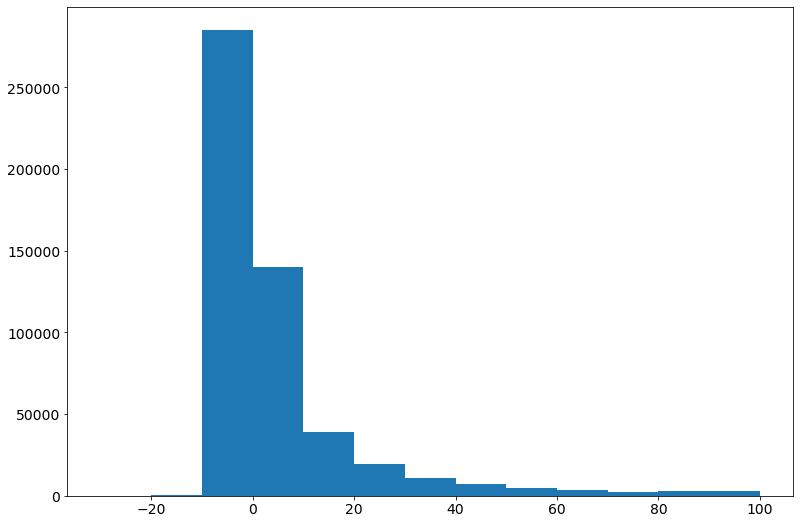

In [125]:
plt.hist(regr.predict(X_test), bins=[-30, -20, -10, 0, 10, 20, 30, 40, 50, 60, 70, 80, 100])

In [126]:
len([item for item in regr.predict(X_test) if item >= 0])

237585

In [124]:
len(regr.predict(X_test))

523104

In [127]:
rf_pipe =  Pipeline([
    ('imputer', SimpleImputer()),
    ('rf', RandomForestRegressor(random_state=0))
])


In [131]:
train['target'] = target

In [132]:
train.corr()

,num_words_title,num_words_abs,productivity,is_main_ratio,sociality,total_venues,mean_citations,top_citations,h_1970,h_1980,h_1990,h_2000,h_2010,h_2020,total_papers,total_citations,avg_citations_paper,avg_citations_year,avg_papers_year,target
num_words_title,1.000000,0.231119,0.068280,-0.157597,0.024473,0.073084,0.026911,0.035450,-0.018187,-0.013317,0.001279,0.025966,0.069270,0.119363,0.030340,0.020588,0.070452,0.071260,0.062509,0.020901
num_words_abs,0.231119,1.000000,0.068326,-0.188482,0.023611,0.085284,0.082608,0.077456,-0.032638,-0.028176,-0.008955,0.027990,0.097885,0.161870,0.010503,0.058744,0.144240,0.120385,0.052997,0.077390
productivity,0.068280,0.068326,1.000000,-0.142733,0.048728,0.697043,-0.001751,0.151374,-0.044252,-0.054716,-0.039188,0.032841,0.247889,0.564034,0.010092,0.001845,0.016133,0.042511,0.054860,-0.005495
is_main_ratio,-0.157597,-0.188482,-0.142733,1.000000,-0.123326,-0.217345,-0.102596,-0.158397,0.012125,-0.031537,-0.095403,-0.181313,-0.301437,-0.374044,-0.108606,-0.081404,-0.158444,-0.156997,-0.142206,-0.076399
sociality,0.024473,0.023611,0.048728,-0.123326,1.000000,0.069726,0.018056,0.044858,0.003965,0.019507,0.041712,0.081027,0.106776,0.136264,0.014652,0.014857,0.022154,0.023822,0.018581,0.009614
total_venues,0.073084,0.085284,0.697043,-0.217345,0.069726,1.000000,0.038446,0.241635,0.014693,0.044037,0.110387,0.245060,0.523061,0.830027,0.054743,0.040394,0.073088,0.082744,0.089904,0.024130
mean_citations,0.026911,0.082608,-0.001751,-0.102596,0.018056,0.038446,1.000000,0.788669,0.045469,0.074087,0.109491,0.151054,0.181152,0.134039,0.052030,0.117101,0.314558,0.145415,0.034673,0.852068
top_citations,0.035450,0.077456,0.151374,-0.158397,0.044858,0.241635,0.788669,1.000000,0.042657,0.083200,0.137473,0.222601,0.321805,0.338139,0.055307,0.100204,0.279104,0.133981,0.049201,0.647259
h_1970,-0.018187,-0.032638,-0.044252,0.012125,0.003965,0.014693,0.045469,0.042657,1.000000,0.706691,0.503331,0.343205,0.213491,0.090751,0.071518,0.115346,0.080298,0.059253,0.016823,0.034380
h_1980,-0.013317,-0.028176,-0.054716,-0.031537,0.019507,0.044037,0.074087,0.083200,0.706691,1.000000,0.758000,0.556616,0.374085,0.176578,0.093940,0.135850,0.114108,0.079930,0.029975,0.055167


In [139]:
ls = list(train.columns[-1:]) + list(train.columns[:-1])

In [141]:
train = train[ls]

In [142]:
train.corr()

,target,num_words_title,num_words_abs,productivity,is_main_ratio,sociality,total_venues,mean_citations,top_citations,h_1970,h_1980,h_1990,h_2000,h_2010,h_2020,total_papers,total_citations,avg_citations_paper,avg_citations_year,avg_papers_year
target,1.000000,0.020901,0.077390,-0.005495,-0.076399,0.009614,0.024130,0.852068,0.647259,0.034380,0.055167,0.081720,0.112499,0.133568,0.094690,0.044987,0.116194,0.376644,0.151636,0.025536
num_words_title,0.020901,1.000000,0.231119,0.068280,-0.157597,0.024473,0.073084,0.026911,0.035450,-0.018187,-0.013317,0.001279,0.025966,0.069270,0.119363,0.030340,0.020588,0.070452,0.071260,0.062509
num_words_abs,0.077390,0.231119,1.000000,0.068326,-0.188482,0.023611,0.085284,0.082608,0.077456,-0.032638,-0.028176,-0.008955,0.027990,0.097885,0.161870,0.010503,0.058744,0.144240,0.120385,0.052997
productivity,-0.005495,0.068280,0.068326,1.000000,-0.142733,0.048728,0.697043,-0.001751,0.151374,-0.044252,-0.054716,-0.039188,0.032841,0.247889,0.564034,0.010092,0.001845,0.016133,0.042511,0.054860
is_main_ratio,-0.076399,-0.157597,-0.188482,-0.142733,1.000000,-0.123326,-0.217345,-0.102596,-0.158397,0.012125,-0.031537,-0.095403,-0.181313,-0.301437,-0.374044,-0.108606,-0.081404,-0.158444,-0.156997,-0.142206
sociality,0.009614,0.024473,0.023611,0.048728,-0.123326,1.000000,0.069726,0.018056,0.044858,0.003965,0.019507,0.041712,0.081027,0.106776,0.136264,0.014652,0.014857,0.022154,0.023822,0.018581
total_venues,0.024130,0.073084,0.085284,0.697043,-0.217345,0.069726,1.000000,0.038446,0.241635,0.014693,0.044037,0.110387,0.245060,0.523061,0.830027,0.054743,0.040394,0.073088,0.082744,0.089904
mean_citations,0.852068,0.026911,0.082608,-0.001751,-0.102596,0.018056,0.038446,1.000000,0.788669,0.045469,0.074087,0.109491,0.151054,0.181152,0.134039,0.052030,0.117101,0.314558,0.145415,0.034673
top_citations,0.647259,0.035450,0.077456,0.151374,-0.158397,0.044858,0.241635,0.788669,1.000000,0.042657,0.083200,0.137473,0.222601,0.321805,0.338139,0.055307,0.100204,0.279104,0.133981,0.049201
h_1970,0.034380,-0.018187,-0.032638,-0.044252,0.012125,0.003965,0.014693,0.045469,0.042657,1.000000,0.706691,0.503331,0.343205,0.213491,0.090751,0.071518,0.115346,0.080298,0.059253,0.016823


<AxesSubplot:>

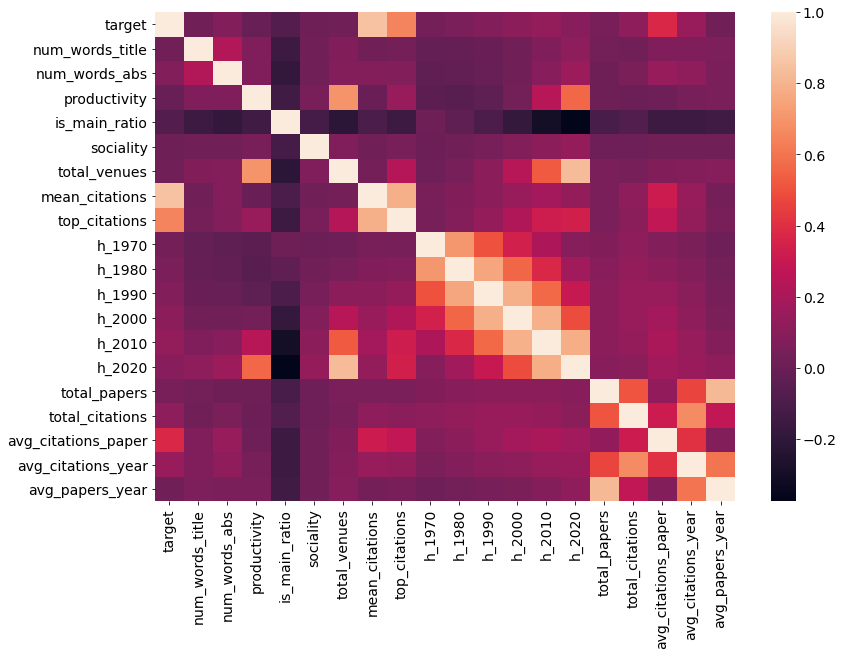

In [143]:
sns.heatmap(train.corr())

,target,num_words_title,num_words_abs,lang,productivity,is_main_ratio,sociality,total_venues,mean_citations,top_citations,...,h_1980,h_1990,h_2000,h_2010,h_2020,total_papers,total_citations,avg_citations_paper,avg_citations_year,avg_papers_year
idx,,,,,,,,,,,,,,,,,,,,,
48a6d2645c62dd994d5b42923a0a4f6a2014978f,0,3,0,ko,0.041667,1.00,0.0,0.0,0.000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
665655aba7427b2501d25c8c16c14fc84ba76dd2,0,2,0,fr,0.013699,1.00,0.0,1.0,0.000,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.000000,0.000000,1.000000
3aa7633b9f1c9410460e841142133bd2cebfc31f,0,8,98,ko,0.100000,0.50,2.0,0.0,0.000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
a3d03f810e90ba148be33e8b6c93656ecfb4280c,0,16,0,en,0.020833,1.00,0.0,0.0,0.000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
9c46bdf1d44862e46db5059b67caaccabb983181,0,13,265,None,0.333333,1.00,0.0,0.0,0.000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
a9239c190e1ae39515d471365b5f2a90de6b3269,20,7,245,en,0.088235,0.25,2.0,2.5,69.625,179.0,...,0.0,1.0,1.0,2.0,3.0,287.0,6046.0,21.066202,111.962963,5.314815
24ec3b97446e17c21e1e0462fcf4db43074b591a,0,16,227,en,0.066667,0.50,5.0,1.0,0.000,0.0,...,0.0,0.0,0.0,0.0,0.0,60.0,111.0,1.850000,3.363636,1.818182
970ee38bbfe7fb38f2cece5ff15859ac08a15da4,0,3,0,ja,0.090909,1.00,0.0,0.0,0.000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000


In [147]:
%%time
cross_val_model(rf_pipe, X_train[:10000], y_train[:10000], scoring='r2', cv=5)

r2 = 0.27287511706717205 +- 0.7650574300987146
CPU times: user 13.8 s, sys: 711 µs, total: 13.8 s
Wall time: 13.8 s


In [154]:
import random



def select_subsample(ls, subsample_size=0.02):
    return [ind for ind in ls if random.random() < subsample_size]

In [156]:
X_train['target'] = y_train
tr = X_train.loc[select_subsample(X_train.index)]

/home/student/miniconda2/envs/pubtrendsv2/lib/python3.7/site-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


In [158]:
X_train_min = tr.drop(columns=['target'])
y_train_min = tr['target']

In [162]:

cross_val_model(lin, X_train_min, y_train_min, scoring='r2', cv=5)

r2 = -0.09376210534535741 +- 1.1732636637795806


/home/student/miniconda2/envs/pubtrendsv2/lib/python3.7/site-packages/sklearn/linear_model/_ridge.py:148: LinAlgWarning: Ill-conditioned matrix (rcond=5.05195e-23): result may not be accurate.
  overwrite_a=True).T
/home/student/miniconda2/envs/pubtrendsv2/lib/python3.7/site-packages/sklearn/linear_model/_ridge.py:148: LinAlgWarning: Ill-conditioned matrix (rcond=5.29527e-23): result may not be accurate.
  overwrite_a=True).T


In [160]:
X_train_min

,num_words_title,num_words_abs,productivity,is_main_ratio,sociality,total_venues,mean_citations,top_citations,h_1970,h_1980,...,de,en,es,fr,it,ja,ko,pt,ru,zh-cn
idx,,,,,,,,,,,,,,,,,,,,,
bfa30113728cfa371b3bdf9614375692e103508d,12,0,0.030303,1.000000,0.000000,0.0,0.00000,0.0,0.0,0.0,...,0,1,0,0,0,0,0,0,0,0
355c88eb463a1c8e672f09388cc02f3429c8f840,26,246,0.014184,1.000000,0.000000,2.0,4.50000,6.0,1.0,1.0,...,0,1,0,0,0,0,0,0,0,0
47f7bee2fac32fd5f1d746ce96b66deab2d140f0,4,0,0.011364,1.000000,0.000000,0.0,0.00000,0.0,0.0,0.0,...,1,0,0,0,0,0,0,0,0,0
462253c5bb98dd27c7193c3e2868cd75168183b0,11,101,0.167582,0.300000,1.300000,3.0,16.35000,45.5,0.0,0.0,...,0,1,0,0,0,0,0,0,0,0
b8ac04c80901844ae3bb026fc0576fb054a83a25,2,0,0.125000,0.500000,1.000000,0.0,0.00000,0.0,0.0,0.0,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48bcbfa1166e09393614b0311dcb3671595c4a2c,11,71,0.100000,1.000000,0.000000,1.0,0.00000,0.0,0.0,0.0,...,0,1,0,0,0,0,0,0,0,0
8bed629f16620c02d5f0235c8bb8d645740f0c22,10,84,0.083333,1.000000,0.000000,1.0,1.00000,1.0,0.0,0.0,...,0,1,0,0,0,0,0,0,0,0
d39ee2801be3668eadd485789d03603369223cbd,4,0,0.320000,0.250000,2.250000,6.0,5.50000,17.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0


In [57]:
!pwd

/home/student/pubtrends


### Create write mean and citations for authors
Поскольку статей очень много, то логично взять статьи после 1970 года и для них для всех посчитать сколько у них было цитат в каждый год. Из этого гораздо проще и честнее можно посчитать для каждого автора его среднюю цитируемость.

In [6]:
import logging


logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)s: %(message)s')


def make_citations(start=1970, end=2022):
    logging.info("Start processing citations")
    for year in range(start, end):
        logging.info(f'Calculating citations for {year} year')
        query = f'''
                        alter table sspublications_sample add column if not exists c_{year} int default 0;
                        update sspublications_sample set c_{year} = t.res
                            from (select ssid_in, sum(case when out_year - in_year >= 0 and out_year <= {year} and in_year <= {year} then 1 else 0 end) as res
                            from sscit_sample group by sscit_sample.ssid_in) as t where t.ssid_in = sspublications_sample.ssid;
        '''
        writer.execute_custom_query(query=query)

In [7]:
make_citations(start=2011)

2021-08-18 23:21:40,017 INFO: Start processing citations
2021-08-18 23:21:40,019 INFO: Calculating citations for 2011 year
2021-08-18 23:22:21,730 INFO: Calculating citations for 2012 year
2021-08-18 23:22:58,610 INFO: Calculating citations for 2013 year
2021-08-18 23:23:36,287 INFO: Calculating citations for 2014 year
2021-08-18 23:24:14,409 INFO: Calculating citations for 2015 year
2021-08-18 23:24:53,249 INFO: Calculating citations for 2016 year
2021-08-18 23:25:32,970 INFO: Calculating citations for 2017 year
2021-08-18 23:26:14,616 INFO: Calculating citations for 2018 year
2021-08-18 23:26:57,280 INFO: Calculating citations for 2019 year
2021-08-18 23:27:46,734 INFO: Calculating citations for 2020 year
2021-08-18 23:28:34,594 INFO: Calculating citations for 2021 year


In [ ]:
%%time
query_id = '''select author_id from authors;'''
query_res = loader.custom_query(query=query_id) 
data_hindex = {item[0]: [0, 0, 0, 0, 0, 0] for item in query_res}

for idx, year in enumerate(range(1970, 2021, 10)):
    q = f'''select author_id, c_{year} from authors_papers left join sspublications_sample on authors_papers.ssid = sspublications_sample.ssid'''
    tmp_data = loader.custom_query(query=q)
    citations = defaultdict(list)
    for a_id, cit in tmp_data:
        citations[a_id].append(cit)

    result = {a_id: hindex(citations[a_id]) for a_id in citations}
    for a_id in result:
        data_hindex[a_id][idx] = result[a_id]

In [16]:
%%time
q_p = '''select ssid, array_agg(author_id) from authors_papers group by ssid;'''
q_a = f'''select ssid, year, {', '.join(map(lambda x: f'c_{x}', range(1970, 2022)))} from sspublications_sample;'''

data_p = loader.custom_query(q_p)
data_a = loader.custom_query(q_a)

CPU times: user 9.57 s, sys: 765 ms, total: 10.3 s
Wall time: 27.4 s


In [73]:
papers = {key: val for key, val in data_p}
authors = defaultdict(list)
citations = {}
years = {}

In [74]:
for ssid, year, *cits in tqdm(data_a):
    citations[ssid] = cits
    years[ssid] = year
    if ssid in papers:
        for a_id in papers[ssid]:
            authors[a_id].append((ssid, year))
authors = dict(authors)

In [72]:
authors_dfs = {key: pd.DataFrame(val, columns=['ssid', 'year']) for key, val in tqdm(authors.items())}

In [95]:
set(authors_dfs[17603][authors_dfs[17603].year <= 1990].ssid)

{'330ccd929b6c1d7fa5058a456a78dce4aa337da2',
 '64d67e33e2247aca2dd1a1c0d6f21368e86cdc55',
 'c70ee03a871fce6d3cfc0d75db79f2cd630c20f0'}

In [112]:
features_s = {}
papers_s = {'330ccd929b6c1d7fa5058a456a78dce4aa337da2': papers['330ccd929b6c1d7fa5058a456a78dce4aa337da2']}
for ssid in tqdm(papers_s):
    try:
        if years[ssid] is not None and years[ssid] >= 1970:
            ls_mean, ls_mx, ls_mn = [], [], []
            for a_id in papers_s[ssid]:
                print(a_id)
                y_hat = years[ssid]
                a_papers = set(authors_dfs[a_id][authors_dfs[a_id].year <= y_hat].ssid)
                a_papers.discard(ssid)
                print(a_papers)
                tmp = [citations[el][y_hat - 1970] for el in a_papers]
                print(tmp)
                if tmp:
                    mean, mx, mn = np.mean(tmp), max(tmp), min(tmp)
                else:
                    mean, mx, mn = 0, 0, 0
                ls_mean.append(mean)
                ls_mx.append(mx)
                ls_mn.append(mn)
            res_mean, res_mx, res_mn = np.mean(ls_mean), np.mean(ls_mx), np.mean(ls_mn)
        else:
            res_mean, res_mx, res_mn = 0, 0, 0
        features_s[ssid] = (res_mean, res_mx, res_mn)   
    except Exception as e:
        print(years[ssid])

17603
{'64d67e33e2247aca2dd1a1c0d6f21368e86cdc55', 'c70ee03a871fce6d3cfc0d75db79f2cd630c20f0'}
[31, 0]



In [109]:
features_s

{'330ccd929b6c1d7fa5058a456a78dce4aa337da2': (15.5, 31.0, 0.0)}

In [105]:
set(authors_dfs[2728960][authors_dfs[2728960].year <= 1990].ssid)

{'64d67e33e2247aca2dd1a1c0d6f21368e86cdc55'}

In [107]:
papers['330ccd929b6c1d7fa5058a456a78dce4aa337da2']

[17603]

In [102]:
features['330ccd929b6c1d7fa5058a456a78dce4aa337da2']

(15.5, 31.0, 0.0)

In [130]:
features['64d67e33e2247aca2dd1a1c0d6f21368e86cdc55']

(0.0, 0.0, 0.0)

In [80]:
features = {}
for ssid in tqdm(papers):
    try:
        if years[ssid] is not None and years[ssid] >= 1970:
            ls_mean, ls_mx, ls_mn = [], [], []
            for a_id in papers[ssid]:
                y_hat = years[ssid]
                a_papers = set(authors_dfs[a_id][authors_dfs[a_id].year <= y_hat].ssid)
                a_papers.discard(ssid)
                tmp = [citations[el][y_hat - 1970] for el in a_papers]
                if tmp:
                    mean, mx, mn = np.mean(tmp), max(tmp), min(tmp)
                else:
                    mean, mx, mn = 0, 0, 0
                ls_mean.append(mean)
                ls_mx.append(mx)
                ls_mn.append(mn)
            res_mean, res_mx, res_mn = np.mean(ls_mean), np.mean(ls_mx), np.mean(ls_mn)
        else:
            res_mean, res_mx, res_mn = 0, 0, 0
        features[ssid] = (res_mean, res_mx, res_mn)   
    except Exception as e:
        print(years[ssid])

In [139]:
total_df = pd.read_csv('tmp_data/total_df.csv')
total_df = total_df.set_index('idx')
total_df['min_citations'] = [0 for _ in range(len(total_df))]

In [141]:
d_total = total_df.to_dict('index')

In [142]:
for key in tqdm(features):
    mean, mx, mn = features[key]
    d_total[key]['mean_citations'] = mean
    d_total[key]['top_citations'] = mx
    d_total[key]['min_citations'] = mn

In [143]:
total = defaultdict(list)

for key in tqdm(d_total):
    total['idx'].append(key)
    for k, v in d_total[key].items():
        total[k].append(v)
total = dict(total)
total_df = pd.DataFrame(data=total)
total_df = total_df.set_index('idx')
total_df

,year,c2,c5,c_all,num_of_authors,num_words_title,num_words_abs,lang,productivity,is_main_ratio,...,h_1990,h_2000,h_2010,h_2020,total_papers,total_citations,avg_citations_paper,avg_citations_year,avg_papers_year,min_citations
idx,,,,,,,,,,,,,,,,,,,,,
23e4a656ae4b11fabd7d4d649ba511c9d537ab22,1989.0,0,0,0,4,5,0,es,0.069206,0.500000,...,0.0,0.0,0.5,0.5,0.0,0.0,0.000000,0.000000,0.000000,0.000000
84a6f323446cfd471ea6169260b3c9fca85b4973,2008.0,2,9,18,4,11,101,en,0.855714,0.146341,...,0.0,0.5,1.5,6.0,14.0,166.0,11.857143,13.833333,1.166667,0.000000
543853285ceaa41346b54c81b4a16d53a67990bf,2019.0,0,0,0,2,14,0,en,0.333333,0.500000,...,0.0,0.0,0.0,0.0,37.0,339.0,9.162162,14.739130,1.608696,0.000000
895d8c3f6262a731092c2a893f6affcf35d4535e,2011.0,0,0,0,3,5,162,en,0.136364,0.250000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000
e667dc7114465832612755ca6c9e81f50017e533,2010.0,0,0,1,1,15,155,es,0.083333,1.000000,...,0.0,0.0,0.0,1.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7f294e6ebccd5492a5540c659b781b4cb9fea4b6,1983.0,0,0,0,1,6,0,en,0.051282,1.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000
9df330adb2377560764636ed589a95997bf4e81d,2006.0,9,24,80,11,15,224,en,0.148897,0.000000,...,0.0,0.0,1.5,2.0,826.0,41459.0,50.192494,609.691176,12.147059,0.000000
7a672f3bc34bd7cf068fda4c4a47b0ec1fc1f5fc,2009.0,3,3,4,2,13,354,en,0.824519,0.298246,...,0.0,0.0,1.5,6.0,38.0,655.0,17.236842,36.388889,2.111111,0.000000


In [146]:
total_df.to_csv('tmp_data/total_dfv2.csv')